# Initial Multi-View Deep Learning Model for RUL Prediction

This notebook develops an initial multi-view deep learning model for C-MAPSS FD001 RUL prediction. The model combines a raw sensor sequence view with a derived degradation feature view. The objective is to evaluate whether fusing these views improves over the GRU sequence baseline and narrows the gap with the best classical baseline.

## 1. Imports and Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.20.0
GPU available: True


## 1b. Colab Path Setup

Run this cell on Google Colab. Mount Drive and set paths before running the rest of the notebook.
Upload all Feature Set B and C CSVs plus the window-aligned comparison CSV to Drive before running.

In [2]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Dissertation/Project/dissertation-rul-xai'
else:
    BASE = '..'

DATA_DIR    = f'{BASE}/data/processed'
METRICS_DIR = f'{BASE}/reports/metrics'
FIG_DIR     = f'{BASE}/reports/figures'
PRED_DIR    = f'{BASE}/reports/predictions'
MODEL_DIR   = f'{BASE}/models/multiview'
ARRAY_DIR   = f'{BASE}/data/processed/multiview'

for d in [METRICS_DIR, FIG_DIR, PRED_DIR, MODEL_DIR, ARRAY_DIR]:
    os.makedirs(d, exist_ok=True)

print('Paths set up.')

Mounted at /content/drive
Paths set up.


## 2. Load Processed Data

In [3]:
train_b = pd.read_csv(f'{DATA_DIR}/train_b_fd001.csv')
val_b   = pd.read_csv(f'{DATA_DIR}/val_b_fd001.csv')
test_b  = pd.read_csv(f'{DATA_DIR}/test_b_fd001.csv')

train_c = pd.read_csv(f'{DATA_DIR}/train_c_fd001.csv')
val_c   = pd.read_csv(f'{DATA_DIR}/val_c_fd001.csv')
test_c  = pd.read_csv(f'{DATA_DIR}/test_c_fd001.csv')

print('train_b:', train_b.shape)
print('val_b:  ', val_b.shape)
print('test_b: ', test_b.shape)
print('train_c:', train_c.shape)
print('val_c:  ', val_c.shape)
print('test_c: ', test_c.shape)

train_b: (16340, 18)
val_b:   (4291, 18)
test_b:  (13096, 18)
train_c: (16340, 61)
val_c:   (4291, 61)
test_c:  (13096, 61)


## 3. Define Feature Columns

The multi-view model uses two input views. The sensor sequence view uses selected raw sensors over a 30-cycle window. The derived degradation view uses rolling statistics, delta features and cycle_index at the prediction cycle. Metadata and target columns are excluded from model inputs.

In [4]:
target_col    = 'RUL_capped'
metadata_cols = ['unit_number', 'time_in_cycles', 'RUL', 'RUL_capped']

sensor_cols = [c for c in train_b.columns if c not in metadata_cols]

derived_cols = [
    c for c in train_c.columns
    if c.endswith('_rmean') or c.endswith('_rstd') or c.endswith('_delta') or c == 'cycle_index'
]

print(f'Sensor sequence features:      {len(sensor_cols)}')
print(f'Derived degradation features:  {len(derived_cols)}')

Sensor sequence features:      14
Derived degradation features:  43


In [5]:
for col in metadata_cols:
    assert col not in sensor_cols, f'Metadata column in sensor features: {col}'
    assert col not in derived_cols, f'Metadata column in derived features: {col}'

assert 'time_in_cycles' not in derived_cols
assert 'cycle_index' in derived_cols

raw_overlap = set(sensor_cols).intersection(set(derived_cols))
assert len(raw_overlap) == 0, f'Raw sensors repeated in derived view: {raw_overlap}'

print('All safety checks passed.')
print(f'View separation confirmed: no overlap between sensor and derived columns.')

All safety checks passed.
View separation confirmed: no overlap between sensor and derived columns.


## 4. Create Multi-View Windowed Dataset

For each sample, the sensor sequence view provides a 30-cycle window of raw sensor measurements, and the derived degradation view provides the derived features at the final cycle of that window. Both views share the same prediction target: capped RUL at the final cycle.

In [6]:
WINDOW_SIZE = 30
STRIDE      = 1

def create_multiview_windows(b_df, c_df, sensor_cols, derived_cols, target_col,
                              window_size=30, stride=1):
    X_seq, X_derived, y, meta = [], [], [], []

    c_lookup = c_df.set_index(['unit_number', 'time_in_cycles'])

    for unit, unit_df in b_df.groupby('unit_number'):
        unit_df = unit_df.sort_values('time_in_cycles').reset_index(drop=True)

        sensor_values = unit_df[sensor_cols].values.astype(np.float32)
        target_values = unit_df[target_col].values.astype(np.float32)
        cycles        = unit_df['time_in_cycles'].values
        raw_rul       = unit_df['RUL'].values

        if len(unit_df) < window_size:
            continue

        for end_idx in range(window_size - 1, len(unit_df), stride):
            start_idx = end_idx - window_size + 1
            cycle     = cycles[end_idx]

            key = (unit, cycle)
            if key not in c_lookup.index:
                continue

            derived_values = c_lookup.loc[key, derived_cols].values.astype(np.float32)

            X_seq.append(sensor_values[start_idx:end_idx + 1])
            X_derived.append(derived_values)
            y.append(target_values[end_idx])
            meta.append({
                'unit_number':    unit,
                'time_in_cycles': cycle,
                'RUL':            raw_rul[end_idx],
                'RUL_capped':     target_values[end_idx]
            })

    return (
        np.array(X_seq,     dtype=np.float32),
        np.array(X_derived, dtype=np.float32),
        np.array(y,         dtype=np.float32),
        pd.DataFrame(meta)
    )

In [7]:
X_train_seq, X_train_der, y_train, train_meta = create_multiview_windows(
    train_b, train_c, sensor_cols, derived_cols, target_col, WINDOW_SIZE, STRIDE
)
X_val_seq, X_val_der, y_val, val_meta = create_multiview_windows(
    val_b, val_c, sensor_cols, derived_cols, target_col, WINDOW_SIZE, STRIDE
)
X_test_seq, X_test_der, y_test, test_meta = create_multiview_windows(
    test_b, test_c, sensor_cols, derived_cols, target_col, WINDOW_SIZE, STRIDE
)

print(f'X_train_seq: {X_train_seq.shape}   (samples, timesteps, features)')
print(f'X_train_der: {X_train_der.shape}')
print(f'y_train:     {y_train.shape}')
print()
print(f'X_val_seq:   {X_val_seq.shape}')
print(f'X_val_der:   {X_val_der.shape}')
print(f'y_val:       {y_val.shape}')
print()
print(f'Train units: {train_meta["unit_number"].nunique()}')
print(f'Val units:   {val_meta["unit_number"].nunique()}')

X_train_seq: (14020, 30, 14)   (samples, timesteps, features)
X_train_der: (14020, 43)
y_train:     (14020,)

X_val_seq:   (3711, 30, 14)
X_val_der:   (3711, 43)
y_val:       (3711,)

Train units: 80
Val units:   20


In [8]:
assert len(X_train_seq) == len(X_train_der) == len(y_train)
assert len(X_val_seq)   == len(X_val_der)   == len(y_val)
assert not np.isnan(X_train_seq).any()
assert not np.isnan(X_train_der).any()
assert not np.isnan(y_train).any()
print('Array safety checks passed.')

Array safety checks passed.


## 5. Save Multi-View Arrays

In [9]:
np.savez_compressed(
    f'{ARRAY_DIR}/train_multiview_fd001_window{WINDOW_SIZE}.npz',
    X_seq=X_train_seq, X_derived=X_train_der, y=y_train
)
np.savez_compressed(
    f'{ARRAY_DIR}/val_multiview_fd001_window{WINDOW_SIZE}.npz',
    X_seq=X_val_seq, X_derived=X_val_der, y=y_val
)
train_meta.to_csv(f'{ARRAY_DIR}/train_multiview_meta_fd001_window{WINDOW_SIZE}.csv', index=False)
val_meta.to_csv(  f'{ARRAY_DIR}/val_multiview_meta_fd001_window{WINDOW_SIZE}.csv',   index=False)
print('Multi-view arrays saved.')

Multi-view arrays saved.


## 6. Evaluation Function

In [10]:
def evaluate_predictions(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, 125)
    rmse   = root_mean_squared_error(y_true, y_pred)
    mae    = mean_absolute_error(y_true, y_pred)
    r2     = r2_score(y_true, y_pred)
    return round(float(rmse), 4), round(float(mae), 4), round(float(r2), 4)

## 7. Model Architecture: Derived-Only MLP (Ablation)

A simple MLP trained on the derived degradation feature view only. This ablation model shows how much performance the derived feature view contributes independently, before combining it with the sequence view.

In [11]:
def build_derived_mlp(n_features):
    derived_input = layers.Input(shape=(n_features,), name='degradation_feature_view')
    x = layers.Dense(64, activation='relu')(derived_input)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    output = layers.Dense(1, name='rul_prediction')(x)

    model = models.Model(inputs=derived_input, outputs=output, name='DerivedOnlyMLP')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
    return model

derived_mlp = build_derived_mlp(X_train_der.shape[1])
derived_mlp.summary()

Model: "DerivedOnlyMLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ degradation_feature_view        │ (None, 43)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rul_prediction (Dense)          │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Model Architecture: Multi-View GRU Fusion

The fusion model has two branches. The GRU branch encodes the raw sensor sequence view, while the MLP branch encodes the derived degradation feature view. The two representations are concatenated and passed through dense layers to predict capped RUL.

In [12]:
def build_multiview_gru_model(window_size, n_sensor_features, n_derived_features):
    seq_input = layers.Input(
        shape=(window_size, n_sensor_features), name='sensor_sequence_view'
    )
    seq_x = layers.GRU(64, return_sequences=False, name='sensor_gru_encoder')(seq_input)
    seq_x = layers.Dropout(0.2)(seq_x)

    derived_input = layers.Input(
        shape=(n_derived_features,), name='degradation_feature_view'
    )
    der_x = layers.Dense(64, activation='relu', name='degradation_dense_1')(derived_input)
    der_x = layers.Dropout(0.2)(der_x)
    der_x = layers.Dense(32, activation='relu', name='degradation_dense_2')(der_x)

    fused  = layers.Concatenate(name='view_fusion')([seq_x, der_x])
    z      = layers.Dense(64, activation='relu', name='fusion_dense_1')(fused)
    z      = layers.Dropout(0.2)(z)
    z      = layers.Dense(32, activation='relu', name='fusion_dense_2')(z)
    output = layers.Dense(1, name='rul_prediction')(z)

    model = models.Model(
        inputs=[seq_input, derived_input], outputs=output, name='MultiViewGRUFusion'
    )
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
    return model

fusion_model = build_multiview_gru_model(
    WINDOW_SIZE, X_train_seq.shape[2], X_train_der.shape[1]
)
fusion_model.summary()

Model: "MultiViewGRUFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ degradation_featur… │ (None, 43)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_sequence_vi… │ (None, 30, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ degradation_dense_1 │ (None, 64)        │      2,816 │ degradation_feat… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_gru_encoder  │ (None, 64)        │     15,360 │ sensor_sequence_… │
│ (GRU)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ degradation_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ sensor_gru_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ degradation_dense_2 │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ view_fusion         │ (None, 96)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ degradation_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_1      │ (None, 64)        │      6,208 │ view_fusion[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ fusion_dense_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_2      │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_prediction      │ (None, 1)         │         33 │ fusion_dense_2[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,577 (111.63 KB)

 Trainable params: 28,577 (111.63 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Training Configuration

Early stopping is used to reduce overfitting. The validation split remains engine-level, so validation units are not mixed with training units.

In [13]:
EPOCHS     = 60
BATCH_SIZE = 128

def get_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1
        )
    ]

## 10. Train Derived-Only MLP

In [14]:
history_derived = derived_mlp.fit(
    X_train_der, y_train,
    validation_data=(X_val_der, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)

derived_pred = np.clip(derived_mlp.predict(X_val_der, verbose=0).flatten(), 0, 125)
derived_rmse, derived_mae, derived_r2 = evaluate_predictions(y_val, derived_pred)

derived_mlp.save(f'{MODEL_DIR}/DerivedOnlyMLP_window{WINDOW_SIZE}_fd001.keras')

print(f'DerivedOnlyMLP  RMSE: {derived_rmse}  MAE: {derived_mae}  R2: {derived_r2}')

Epoch 1/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 5624.8018 - mae: 64.3993 - val_loss: 1565.2385 - val_mae: 32.5417 - learning_rate: 0.0010
Epoch 2/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1146.2441 - mae: 27.2082 - val_loss: 754.4950 - val_mae: 21.9792 - learning_rate: 0.0010
Epoch 3/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 603.6539 - mae: 19.2874 - val_loss: 451.8512 - val_mae: 16.8687 - learning_rate: 0.0010
Epoch 4/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 411.8503 - mae: 15.7131 - val_loss: 368.0539 - val_mae: 15.2645 - learning_rate: 0.0010
Epoch 5/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 367.0752 - mae: 14.6909 - val_loss: 340.5235 - val_mae: 14.6442 - learning_rate: 0.0010
Epoch 6/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 346.6823 - mae: 14.2306 - val_loss: 324.2151 - val_mae: 14.2391 - learning_rate: 0.0010
Epoch 7/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 333.1312 - mae: 13.9512 - val_loss: 305.8527 - v

## 11. Train Multi-View GRU Fusion

In [15]:
history_fusion = fusion_model.fit(
    [X_train_seq, X_train_der], y_train,
    validation_data=([X_val_seq, X_val_der], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)

fusion_pred = np.clip(fusion_model.predict([X_val_seq, X_val_der], verbose=0).flatten(), 0, 125)
fusion_rmse, fusion_mae, fusion_r2 = evaluate_predictions(y_val, fusion_pred)

fusion_model.save(f'{MODEL_DIR}/MultiViewGRUFusion_window{WINDOW_SIZE}_fd001.keras')

print(f'MultiViewGRUFusion  RMSE: {fusion_rmse}  MAE: {fusion_mae}  R2: {fusion_r2}')

Epoch 1/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 2817.7356 - mae: 39.1434 - val_loss: 359.9422 - val_mae: 15.3781 - learning_rate: 0.0010
Epoch 2/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 417.7821 - mae: 16.1618 - val_loss: 256.6349 - val_mae: 12.7373 - learning_rate: 0.0010
Epoch 3/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 339.4204 - mae: 14.3499 - val_loss: 230.3985 - val_mae: 11.8904 - learning_rate: 0.0010
Epoch 4/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 303.1968 - mae: 13.4304 - val_loss: 206.3635 - val_mae: 11.1408 - learning_rate: 0.0010
Epoch 5/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 282.0303 - mae: 12.8761 - val_loss: 198.1559 - val_mae: 10.8269 - learning_rate: 0.0010
Epoch 6/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 271.0671 - mae: 12.6152 - val_loss: 186.8783 - val_mae: 10.4169 - learning_rate: 0.0010
Epoch 7/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 255.9417 - mae: 12.1851 - val_loss: 178.5969 -

## 12. Save Results and Predictions

In [16]:
multiview_results = pd.DataFrame([
    {
        'model':            'DerivedOnlyMLP',
        'views_used':       'derived_degradation_view',
        'window_size':      WINDOW_SIZE,
        'validation_rmse':  derived_rmse,
        'validation_mae':   derived_mae,
        'validation_r2':    derived_r2,
    },
    {
        'model':            'MultiViewGRUFusion',
        'views_used':       'sensor_sequence_view + derived_degradation_view',
        'window_size':      WINDOW_SIZE,
        'validation_rmse':  fusion_rmse,
        'validation_mae':   fusion_mae,
        'validation_r2':    fusion_r2,
    }
]).sort_values('validation_rmse').reset_index(drop=True)

multiview_results.to_csv(f'{METRICS_DIR}/multiview_deep_learning_results_fd001.csv', index=False)
print(multiview_results.to_string(index=False))

             model                                      views_used  window_size  validation_rmse  validation_mae  validation_r2
MultiViewGRUFusion sensor_sequence_view + derived_degradation_view           30          12.0657          8.9406         0.9168
    DerivedOnlyMLP                        derived_degradation_view           30          13.1451          9.4204         0.9013


In [17]:
derived_pred_df = val_meta.copy()
derived_pred_df['prediction'] = derived_pred
derived_pred_df['model']      = 'DerivedOnlyMLP'
derived_pred_df['views_used'] = 'derived_degradation_view'
derived_pred_df.to_csv(
    f'{PRED_DIR}/val_predictions_DerivedOnlyMLP_window{WINDOW_SIZE}_fd001.csv', index=False
)

fusion_pred_df = val_meta.copy()
fusion_pred_df['prediction'] = fusion_pred
fusion_pred_df['model']      = 'MultiViewGRUFusion'
fusion_pred_df['views_used'] = 'sensor_sequence_view + derived_degradation_view'
fusion_pred_df.to_csv(
    f'{PRED_DIR}/val_predictions_MultiViewGRUFusion_window{WINDOW_SIZE}_fd001.csv', index=False
)

print('Predictions saved.')

Predictions saved.


## 13. Comparison Against Earlier Baselines

In [18]:
aligned_comparison = pd.read_csv(
    f'{METRICS_DIR}/classical_vs_deep_window_aligned_comparison_fd001.csv'
)

comparison_rows = []
for _, row in aligned_comparison.iterrows():
    comparison_rows.append({
        'model_group':    row['model_type'],
        'model':          row['model'],
        'feature_or_views': row['feature_set'],
        'validation_rmse': row['validation_rmse'],
        'validation_mae':  row['validation_mae'],
        'validation_r2':   row['validation_r2'],
    })

for _, row in multiview_results.iterrows():
    comparison_rows.append({
        'model_group':    'Multi-view Deep Learning',
        'model':          row['model'],
        'feature_or_views': row['views_used'],
        'validation_rmse': row['validation_rmse'],
        'validation_mae':  row['validation_mae'],
        'validation_r2':   row['validation_r2'],
    })

final_comparison_df = pd.DataFrame(comparison_rows).sort_values('validation_rmse').reset_index(drop=True)
final_comparison_df.to_csv(
    f'{METRICS_DIR}/multiview_vs_baselines_comparison_fd001.csv', index=False
)
print(final_comparison_df.to_string(index=False))

             model_group              model                                feature_or_views  validation_rmse  validation_mae  validation_r2
Multi-view Deep Learning MultiViewGRUFusion sensor_sequence_view + derived_degradation_view          12.0657          8.9406         0.9168
               Classical            XGBoost                                               C          12.4894          9.2675         0.9109
Multi-view Deep Learning     DerivedOnlyMLP                        derived_degradation_view          13.1451          9.4204         0.9013
           Deep Learning                GRU                                   B (window=30)          13.1605          9.7182         0.9010
           Deep Learning              CNN1D                                   B (window=30)          18.1509         14.0382         0.8118


## 14. RMSE Comparison Plot

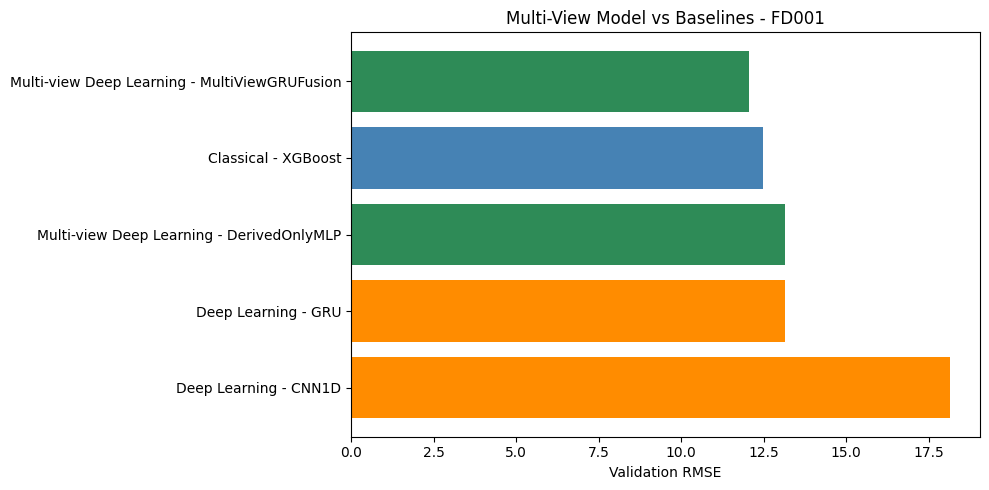

In [19]:
color_map = {
    'Classical':              'steelblue',
    'Deep Learning':          'darkorange',
    'Multi-view Deep Learning': 'seagreen',
}
plot_df = final_comparison_df.sort_values('validation_rmse', ascending=True)
colors  = [color_map.get(g, 'grey') for g in plot_df['model_group']]
labels  = plot_df['model_group'] + ' - ' + plot_df['model']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels, plot_df['validation_rmse'], color=colors)
ax.set_xlabel('Validation RMSE')
ax.set_title('Multi-View Model vs Baselines - FD001')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/multiview_vs_baselines_rmse_fd001.png', dpi=300)
plt.show()

## 15. Training Curves

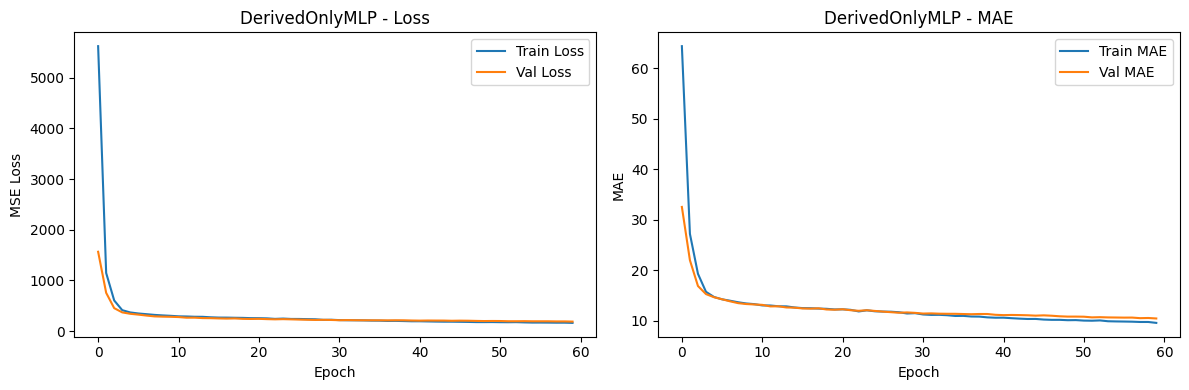

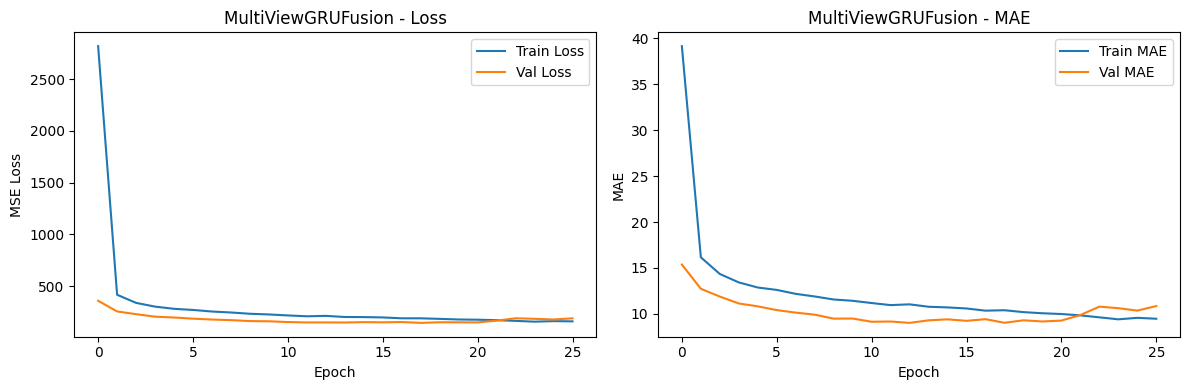

In [20]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()

    axes[1].plot(history.history['mae'],     label='Train MAE')
    axes[1].plot(history.history['val_mae'], label='Val MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].set_title(f'{model_name} - MAE')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/training_curve_{model_name}_fd001.png', dpi=300)
    plt.show()

plot_history(history_derived, 'DerivedOnlyMLP')
plot_history(history_fusion,  'MultiViewGRUFusion')

## 16. Actual vs Predicted - Fusion Model

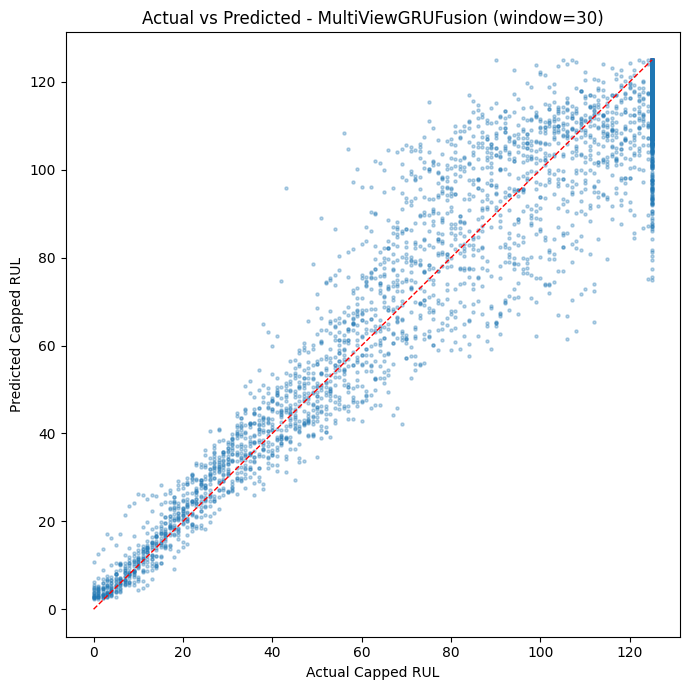

In [21]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(fusion_pred_df['RUL_capped'], fusion_pred_df['prediction'], alpha=0.3, s=5)
ax.plot([0, 125], [0, 125], 'r--', linewidth=1)
ax.set_xlabel('Actual Capped RUL')
ax.set_ylabel('Predicted Capped RUL')
ax.set_title(f'Actual vs Predicted - MultiViewGRUFusion (window={WINDOW_SIZE})')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/actual_vs_predicted_multiview_fd001.png', dpi=300)
plt.show()

## 17. Error Distribution - Fusion Model

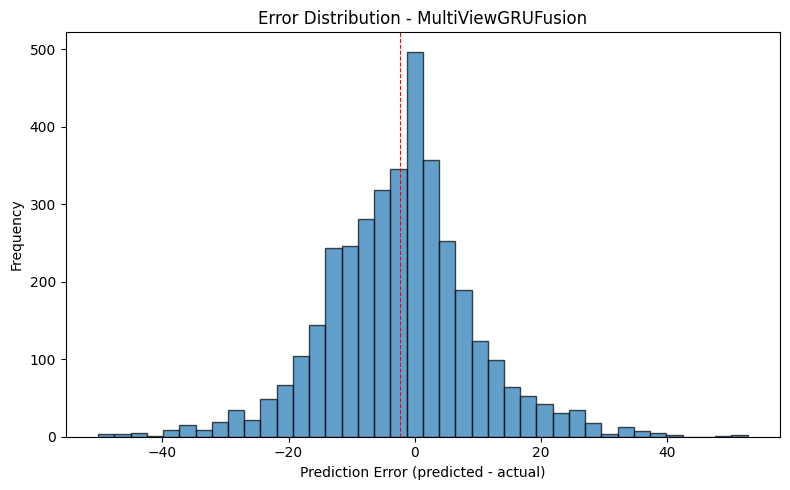

Mean error:   -2.28
Median error: -1.71
Std error:    11.85


In [22]:
fusion_pred_df['error'] = fusion_pred_df['prediction'] - fusion_pred_df['RUL_capped']

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(fusion_pred_df['error'], bins=40, edgecolor='black', alpha=0.7)
ax.axvline(fusion_pred_df['error'].mean(), color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Prediction Error (predicted - actual)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution - MultiViewGRUFusion')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/error_distribution_multiview_fd001.png', dpi=300)
plt.show()

print(f'Mean error:   {fusion_pred_df["error"].mean():.2f}')
print(f'Median error: {fusion_pred_df["error"].median():.2f}')
print(f'Std error:    {fusion_pred_df["error"].std():.2f}')

## 18. Sample Engine Prediction Trajectories - Fusion Model

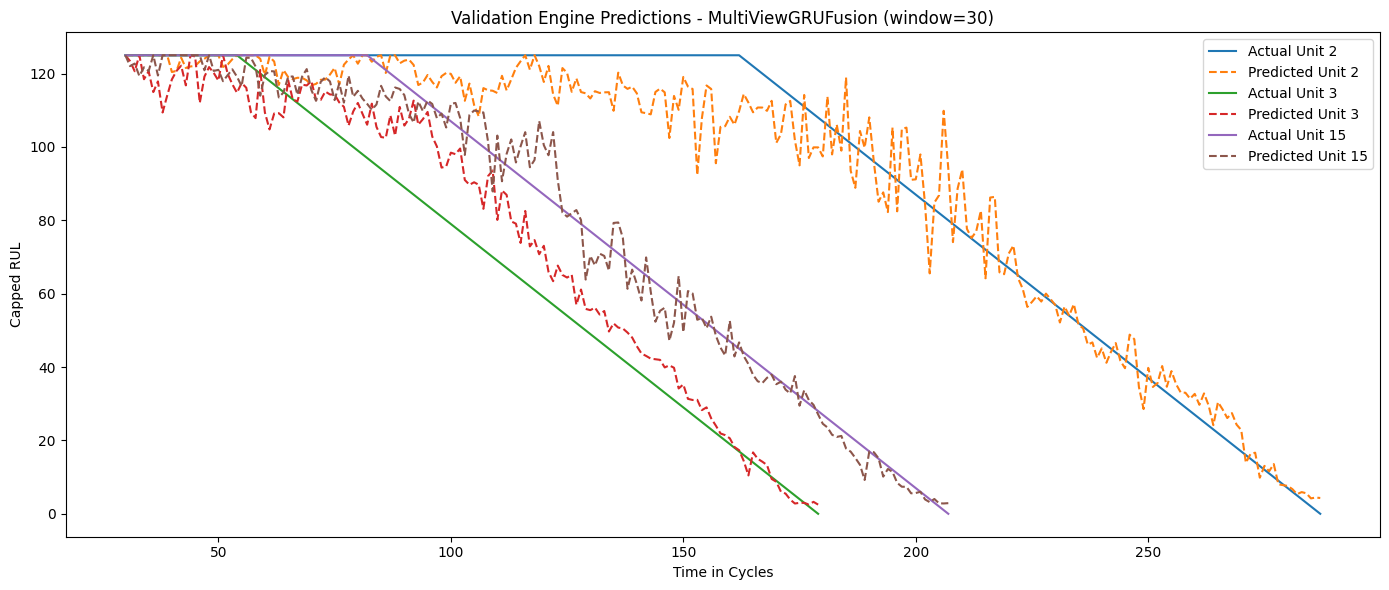

In [23]:
sample_units = fusion_pred_df['unit_number'].drop_duplicates().head(3)

fig, ax = plt.subplots(figsize=(14, 6))
for unit in sample_units:
    unit_df = fusion_pred_df[fusion_pred_df['unit_number'] == unit].sort_values('time_in_cycles')
    ax.plot(unit_df['time_in_cycles'], unit_df['RUL_capped'],
            linewidth=1.5, label=f'Actual Unit {unit}')
    ax.plot(unit_df['time_in_cycles'], unit_df['prediction'],
            linestyle='--', linewidth=1.5, label=f'Predicted Unit {unit}')

ax.set_xlabel('Time in Cycles')
ax.set_ylabel('Capped RUL')
ax.set_title(f'Validation Engine Predictions - MultiViewGRUFusion (window={WINDOW_SIZE})')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/sample_engine_prediction_trajectories_multiview_fd001.png', dpi=300)
plt.show()

## 19. View Ablation Interpretation

The comparison between GRU (from Step 5), DerivedOnlyMLP and MultiViewGRUFusion provides an initial view-ablation analysis. GRU uses only the raw sensor sequence view, DerivedOnlyMLP uses only the derived degradation view, and MultiViewGRUFusion combines both. This helps evaluate whether the fused representation provides added value beyond either view alone.

## 20. Result Interpretation

The initial multi-view fusion result is encouraging. MultiViewGRUFusion achieved the lowest validation RMSE among the evaluated models on the window-aligned validation set. It improved over the GRU sequence-only baseline and the DerivedOnlyMLP degradation-feature-only baseline. This suggests that the two views provide complementary information for RUL prediction. The model also achieved lower validation RMSE than the window-aligned XGBoost baseline, although this result should be treated as an initial validation finding rather than a final conclusion. Additional robustness, explainability and repeated-run checks will be considered in later stages.

In [24]:
gru_rmse    = float(final_comparison_df[final_comparison_df['model'] == 'GRU']['validation_rmse'].iloc[0])
xgb_rmse    = float(final_comparison_df[final_comparison_df['model'] == 'XGBoost']['validation_rmse'].iloc[0])

print('Summary:')
print(f'  XGBoost/C (window-aligned):  RMSE {xgb_rmse:.4f}')
print(f'  GRU/B (Step 5):              RMSE {gru_rmse:.4f}')
print(f'  DerivedOnlyMLP:              RMSE {derived_rmse:.4f}')
print(f'  MultiViewGRUFusion:          RMSE {fusion_rmse:.4f}')
print()

if fusion_rmse < gru_rmse and fusion_rmse < xgb_rmse:
    print('Fusion beat both GRU and XGBoost.')
elif fusion_rmse < gru_rmse:
    print('Fusion improved over GRU but did not beat XGBoost.')
    print('The classical model still leads on the window-aligned evaluation.')
else:
    print('Fusion did not improve over GRU.')
    print('Current architecture may benefit from tuning or regularization.')

Summary:
  XGBoost/C (window-aligned):  RMSE 12.4894
  GRU/B (Step 5):              RMSE 13.1605
  DerivedOnlyMLP:              RMSE 13.1451
  MultiViewGRUFusion:          RMSE 12.0657

Fusion beat both GRU and XGBoost.


## 21. Observations

1. An initial multi-view deep learning model was implemented using two views: raw sensor sequence and derived degradation features.
2. The sensor sequence view uses 30-cycle windows of 14 selected sensor measurements.
3. The derived degradation view uses rolling mean, rolling standard deviation, delta features and cycle_index at the prediction cycle.
4. The validation split remains engine-level, consistent with the leakage prevention strategy used in earlier steps.
5. DerivedOnlyMLP was trained as an ablation model to evaluate the derived feature view independently.
6. MultiViewGRUFusion was trained to evaluate whether combining the two views improves RUL prediction.
7. The multi-view result is compared against GRU, CNN1D and the window-aligned XGBoost classical baseline.
8. This model will be used as the starting point for explainability and robustness analysis in the next phase.

## 22. Generated Artefacts

In [25]:
print('Metrics:')
for f in sorted(os.listdir(METRICS_DIR)):
    if 'multiview' in f:
        print(f'  {f}')

print('\nPredictions:')
for f in sorted(os.listdir(PRED_DIR)):
    if 'MultiView' in f or 'DerivedOnly' in f:
        print(f'  {f}')

print('\nFigures:')
for f in sorted(os.listdir(FIG_DIR)):
    if 'multiview' in f or 'MultiView' in f or 'DerivedOnly' in f:
        print(f'  {f}')

print('\nModels:')
for f in sorted(os.listdir(MODEL_DIR)):
    print(f'  {f}')

print('\nArrays:')
for f in sorted(os.listdir(ARRAY_DIR)):
    print(f'  {f}')

Metrics:
  multiview_deep_learning_results_fd001.csv
  multiview_vs_baselines_comparison_fd001.csv

Predictions:
  val_predictions_DerivedOnlyMLP_window30_fd001.csv
  val_predictions_MultiViewGRUFusion_window30_fd001.csv

Figures:
  actual_vs_predicted_multiview_fd001.png
  error_distribution_multiview_fd001.png
  multiview_vs_baselines_rmse_fd001.png
  sample_engine_prediction_trajectories_multiview_fd001.png
  training_curve_DerivedOnlyMLP_fd001.png
  training_curve_MultiViewGRUFusion_fd001.png

Models:
  DerivedOnlyMLP_window30_fd001.keras
  MultiViewGRUFusion_window30_fd001.keras

Arrays:
  train_multiview_fd001_window30.npz
  train_multiview_meta_fd001_window30.csv
  val_multiview_fd001_window30.npz
  val_multiview_meta_fd001_window30.csv
